In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [4]:
data = pd.read_csv("/content/IMDB Dataset.csv")

In [5]:
data["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [6]:
# positive -> 1
# negative -> 0
data.replace({"sentiment": {"positive": 1, "negative": 0}}, inplace=True)

In [7]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [8]:
train_data, test_data = train_test_split(data, test_size = 0.2, random_state=42)

In [9]:
train_data.shape

(40000, 2)

In [10]:
test_data.shape

(10000, 2)

In [11]:
tokenizer = Tokenizer(num_words = 5000)
tokenizer.fit_on_texts(train_data["review"])

In [12]:
X_train = pad_sequences(tokenizer.texts_to_sequences(train_data["review"]), maxlen=200)
X_test = pad_sequences(tokenizer.texts_to_sequences(test_data["review"]), maxlen=200)

In [13]:
X_train

array([[1935,    1, 1200, ...,  205,  351, 3856],
       [   3, 1651,  595, ...,   89,  103,    9],
       [   0,    0,    0, ...,    2,  710,   62],
       ...,
       [   0,    0,    0, ..., 1641,    2,  603],
       [   0,    0,    0, ...,  245,  103,  125],
       [   0,    0,    0, ...,   70,   73, 2062]], dtype=int32)

In [14]:
X_test

array([[   0,    0,    0, ...,  995,  719,  155],
       [  12,  162,   59, ...,  380,    7,    7],
       [   0,    0,    0, ...,   50, 1088,   96],
       ...,
       [   0,    0,    0, ...,  125,  200, 3241],
       [   0,    0,    0, ..., 1066,    1, 2305],
       [   0,    0,    0, ...,    1,  332,   27]], dtype=int32)

In [15]:
y_train = train_data["sentiment"]
y_test = test_data["sentiment"]

In [16]:
y_train

,sentiment
39087,0
30893,0
45278,1
16398,0
13653,0
...,...
11284,1
44732,1
38158,0
860,1


In [19]:
# LSTM MODEL BUILDING

In [17]:
from tensorflow.keras.callbacks import Callback

In [18]:
from sklearn.metrics import accuracy_score, f1_score

In [20]:
# 2. Enhanced Evaluation Callback
class EvalCallback(Callback):
    def __init__(self, X_test, y_test, percentage):
        self.X_test = X_test
        self.y_test = y_test
        self.percentage = percentage
        self.epoch_metrics = []  # Store metrics for each epoch
        self.accuracy_score = accuracy_score  # Store functions as attributes
        self.f1_score = f1_score

    def on_epoch_end(self, epoch, logs=None):
        y_pred = (self.model.predict(self.X_test) > 0.5).astype(int)
        val_acc = self.accuracy_score(self.y_test, y_pred)
        val_f1 = self.f1_score(self.y_test, y_pred)

        # Store metrics
        self.epoch_metrics.append({
            'epoch': epoch + 1,
            'val_acc': val_acc,
            'val_f1': val_f1
        })

        print(f"Epoch {epoch+1}: val_acc={val_acc:.4f}, val_f1={val_f1:.4f}")

# Initialize storage for all results
all_results = {}

percentages = [0.2, 0.4, 0.6, 0.8, 1.0]

In [ ]:
# 2. Enhanced Evaluation Callback
class EvalCallback(Callback):
    def __init__(self, X_test, y_test, percentage):
        self.X_test = X_test
        self.y_test = y_test
        self.percentage = percentage
        self.epoch_metrics = []  # Store metrics for each epoch
        self.accuracy_score = accuracy_score  # Store functions as attributes
        self.f1_score = f1_score

    def on_epoch_end(self, epoch, logs=None):
        y_pred = (self.model.predict(self.X_test) > 0.5).astype(int)
        val_acc = self.accuracy_score(self.y_test, y_pred)
        val_f1 = self.f1_score(self.y_test, y_pred)

        # Store metrics
        self.epoch_metrics.append({
            'epoch': epoch + 1,
            'val_acc': val_acc,
            'val_f1': val_f1
        })

        print(f"Epoch {epoch+1}: val_acc={val_acc:.4f}, val_f1={val_f1:.4f}")

# Initialize storage for all results
all_results = {}

percentages = [0.2, 0.4, 0.6, 0.8, 1.0]

for p in percentages:
    print(f"\n=== Training with {p*100:.0f}% data ({int(p*len(X_train))} samples) ===")

    # Create subset of training data
    X_sub, _, y_sub, _ = train_test_split(
        X_train, y_train,
        train_size=p,
        random_state=42,
        stratify=y_train
    )

    # Initialize model
    model = Sequential([
        Embedding(input_dim =5000, output_dim = 128, input_length = 200),
        LSTM(128, dropout=0.2, recurrent_dropout = 0.2),
        Dense(1, activation = "sigmoid")
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Initialize callback for this percentage
    eval_callback = EvalCallback(X_test, y_test, p)

    # Train model
    model.fit(
        X_sub, y_sub,
        epochs=3,
        batch_size=64,
        callbacks=[eval_callback],
        verbose=1
    )

    # Store results for this percentage
    all_results[p] = {
        'epoch_metrics': eval_callback.epoch_metrics,
        'final_metrics': {
            'accuracy': accuracy_score(y_test, (model.predict(X_test) > 0.5).astype(int)),
            'f1': f1_score(y_test, (model.predict(X_test) > 0.5).astype(int))
        }
    }

    print(f"Final: Accuracy={all_results[p]['final_metrics']['accuracy']:.4f}, "
          f"F1={all_results[p]['final_metrics']['f1']:.4f}")




=== Training with 20% data (8000 samples) ===
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 102ms/step
Epoch 1: val_acc=0.7761, val_f1=0.7666
125/125 ━━━━━━━━━━━━━━━━━━━━ 121s 886ms/step - accuracy: 0.6123 - loss: 0.6367
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step
Epoch 2: val_acc=0.8147, val_f1=0.8257
125/125 ━━━━━━━━━━━━━━━━━━━━ 152s 966ms/step - accuracy: 0.8443 - loss: 0.3776
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step
Epoch 3: val_acc=0.8337, val_f1=0.8354
125/125 ━━━━━━━━━━━━━━━━━━━━ 142s 968ms/step - accuracy: 0.8892 - loss: 0.2921
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step
Final: Accuracy=0.8337, F1=0.8354

=== Training with 40% data (16000 samples) ===
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step
Epoch 1: val_acc=0.8218, val_f1=0.8265
250/250 ━━━━━━━━━━━━━━━━━━━━ 191s 751ms/step - accuracy: 0.6658 - loss: 0.5969
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step
Epoch 2: val_acc=0.8215, val_f1=0.8359
250/250 

InvalidParameterError: The 'train_size' parameter of train_test_split must be a float in the range (0.0, 1.0), an int in the range [1, inf) or None. Got 1.0 instead.

In [22]:
p = 1.0
print(f"\n=== Training with {p*100:.0f}% data ({int(p*len(X_train))} samples) ===")

    # Create subset of training data

if p < 1.0:
    X_sub, _, y_sub, _ = train_test_split(
        X_train, y_train,
        train_size=p,
        random_state=42,
        stratify=y_train)
else:
    X_sub, y_sub = X_train, y_train


# Initialize model
model = Sequential([
Embedding(input_dim =5000, output_dim = 128, input_length = 200),
LSTM(128, dropout=0.2, recurrent_dropout = 0.2),
Dense(1, activation = "sigmoid")])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

 # Initialize callback for this percentage
eval_callback = EvalCallback(X_test, y_test, p)

    # Train model
model.fit(
X_sub, y_sub,
epochs=3,
batch_size=64,
callbacks=[eval_callback],
verbose=1)

 # Store results for this percentage
all_results[p] = {
'epoch_metrics': eval_callback.epoch_metrics,
'final_metrics': {
'accuracy': accuracy_score(y_test, (model.predict(X_test) > 0.5).astype(int)),
'f1': f1_score(y_test, (model.predict(X_test) > 0.5).astype(int))}
}

print(f"Final: Accuracy={all_results[p]['final_metrics']['accuracy']:.4f}, "
          f"F1={all_results[p]['final_metrics']['f1']:.4f}")


=== Training with 100% data (40000 samples) ===
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 84ms/step
Epoch 1: val_acc=0.8565, val_f1=0.8614
625/625 ━━━━━━━━━━━━━━━━━━━━ 372s 587ms/step - accuracy: 0.7259 - loss: 0.5248
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step
Epoch 2: val_acc=0.8607, val_f1=0.8695
625/625 ━━━━━━━━━━━━━━━━━━━━ 390s 600ms/step - accuracy: 0.8334 - loss: 0.3920
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 75ms/step
Epoch 3: val_acc=0.8835, val_f1=0.8829
625/625 ━━━━━━━━━━━━━━━━━━━━ 383s 602ms/step - accuracy: 0.8697 - loss: 0.3208
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 75ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step
Final: Accuracy=0.8835, F1=0.8829


In [25]:
import numpy as np
import matplotlib.pyplot as plt

In [27]:
import matplotlib.pyplot as plt

# Store final metrics
percentages = [0.2, 0.4, 0.6, 0.8, 1.0]
accuracies = [0.8337, 0.8384, 0.8523, 0.8655, 0.8835]
f1_scores  = [0.8354, 0.8322, 0.8454, 0.8721, 0.8829]


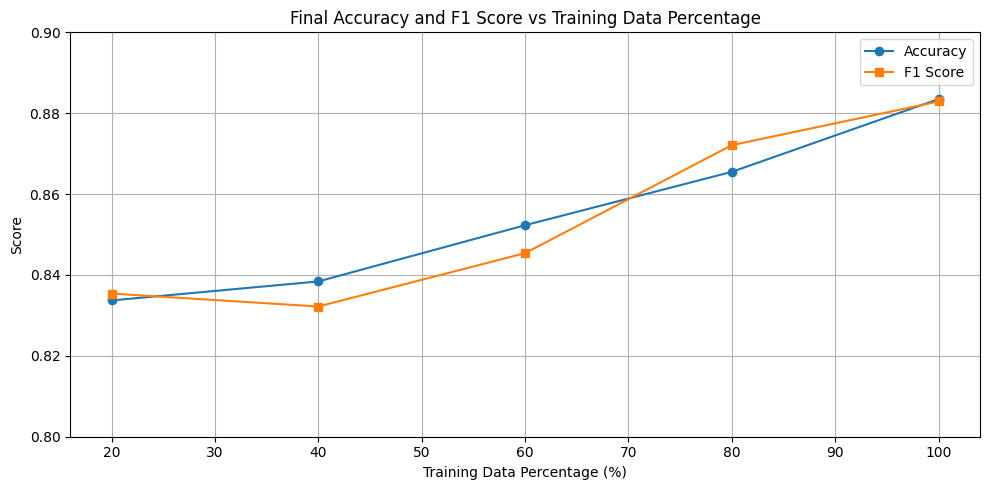

In [28]:
plt.figure(figsize=(10, 5))

plt.plot([p * 100 for p in percentages], accuracies, marker='o', label='Accuracy')
plt.plot([p * 100 for p in percentages], f1_scores, marker='s', label='F1 Score')

plt.title('Final Accuracy and F1 Score vs Training Data Percentage')
plt.xlabel('Training Data Percentage (%)')
plt.ylabel('Score')
plt.ylim(0.8, 0.9)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [29]:
# Data
percentages = [0.2, 0.4, 0.6, 0.8, 1.0]
accuracies = [0.8337, 0.8384, 0.8523, 0.8655, 0.8835]
f1_scores  = [0.8354, 0.8322, 0.8454, 0.8721, 0.8829]

# Print Table
print("\nFinal Results:")
print(f"{'Percentage':>10} | {'Accuracy':>8} | {'F1 Score':>8}")
print("-" * 34)
for p, acc, f1 in zip(percentages, accuracies, f1_scores):
    print(f"{p*100:10.0f}% | {acc:8.4f} | {f1:8.4f}")



Final Results:
Percentage | Accuracy | F1 Score
----------------------------------
        20% |   0.8337 |   0.8354
        40% |   0.8384 |   0.8322
        60% |   0.8523 |   0.8454
        80% |   0.8655 |   0.8721
       100% |   0.8835 |   0.8829


In [30]:
model.save("my_model.keras")

In [31]:
import joblib
joblib.dump(tokenizer, "tokenizer.pkl")

['tokenizer.pkl']

In [32]:
# Building Predictive System

In [33]:
def predictive_system(review):
  sequences = tokenizer.texts_to_sequences([review])
  padded_sequence = pad_sequences(sequences, maxlen=200)
  prediction = model.predict(padded_sequence)
  sentiment = "positive" if prediction[0][0] > 0.5 else "negative"
  return sentiment

In [34]:
predictive_system("This movie was fantastic and amazing")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


'positive'

In [35]:
predictive_system("A trilling adventure with stunning visual")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


'positive'

In [36]:
predictive_system("A visual masterpiece")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


'positive'

In [37]:
predictive_system("Overall long and slow")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


'negative'

In [38]:
#Now prior of this model will be generated by LLM and then  we will be incorporating that
# info and then again train model and compare the
# accuracy vs % of training data used for both models (first model is without any prior info and second one with info of prior)
# accuracy should be high even at low % of training data in model 2 this we have to check

In [41]:
# also prior will be generated with LLM